In [38]:
# 1.load the dataset into a Pandas DataFrame — use pd.read_csv() or pd.read_sql()
# 2 Print df.shape, df.info(), df.dtypes — document what you find in comments
# 3 Check for missing values: df.isnull().sum() — what % is missing per column?
# 4 Run df.describe() — identify 3 observations (e.g. mean vs median, suspicious min/max)
# 5 Run df['col'].value_counts() on at least 1 categorical column
# 6 Plot a histogram for every numeric column — do they look normal or skewed?
# 7 Plot a box plot for at least 2 columns — are there outliers?
# 8 Write a 5-line comment block at the top summarising what you found
# Deliverable: .py script with all 8 steps + charts saved as
# .png files
# Bonus: Use sns.pairplot() on all numeric columns and
# describe what you see


In [39]:
!pip install pandas matplotlib seaborn numpy

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set default plot style
sns.set_style("whitegrid")

## Data Loading and Initial Inspection

In [41]:
# 1. Load the dataset into a Pandas DataFrame
file_path = '../../day_6/enriched_students.csv'
df = pd.read_csv(file_path)

# 2. Print df.shape, df.info(), df.dtypes
print(f"Dataset shape: {df.shape}")
print("\nDataset information:")
print(df.info)
print("\nData types:")
print(df.dtypes)

# Documentation of findings (as comments in this cell)
# Observations from df.shape:
# The dataset has X rows and Y columns.
#
# Observations from df.info():
# (e.g., 'object' type columns for text/categorical, 'int'/'float' for numeric, non-null counts indicate missing values).
# Example: 'column_A' has 1000 entries but only 900 non-null, meaning 100 missing values.
#
# Observations from df.dtypes:
# Confirms the data types inferred by pandas. (e.g., 'column_B' is an integer type, 'column_C' is an object/string type).

Dataset shape: (35, 14)

Dataset information:
<bound method DataFrame.info of         name  math_score  english_score  science_score  social_study_score  \
0       Yara        95.0           92.0             94                91.0   
1      Wyatt        92.0           94.0             91                95.0   
2       Milo        90.0           88.0             92                89.0   
3     Nathan        91.0           88.0             93                87.0   
4      Henry        90.0           85.0             88                95.0   
5      Grace        88.0           92.0             85                90.0   
6   Isabella        85.0           90.0             88                92.0   
7      Alice        85.0           90.0             88                92.0   
8       Ryan        88.0           91.0             85                89.0   
9    Tristan        88.0           84.0             86                85.0   
10      Owen        85.0           87.0             84          

## Missing Value Analysis

In [42]:
# 3. Check for missing values and calculate percentage per column
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

print("Missing values per column:")
print(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))

# Documentation of findings (as comments in this cell)
# (e.g., 'column_X' is missing 25% of its values, 'column_Y' has no missing values).

Missing values per column:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


## Descriptive Statistics

In [43]:
# 4. Run df.describe() and identify 3 observations
df_description = df.describe(include='all')
print("Descriptive statistics for the dataset:")
display(df_description)

# Identify 3 observations (as comments in this cell)
# Observation 1: (e.g., For 'numeric_column_A', the mean is significantly different from the median, suggesting a skewed distribution.)
# Observation 2: (e.g., For 'numeric_column_B', the minimum value is -999, which seems suspicious and might indicate erroneous data or a special coding for missing/unknown values.)
# Observation 3: (e.g., For 'categorical_column_C', the 'top' value appears X times, indicating it's a dominant category.)

Descriptive statistics for the dataset:


,name,math_score,english_score,science_score,social_study_score,math_grade,english_grade,science_grade,social_study_grade,overall_score,overall_grade,passed,score_category,rank
count,35,35.00000,35.000000,35.000000,35.000000,35,35,35,35,35.000000,35,35,35,35.000000
unique,35,NaN,NaN,NaN,NaN,5,4,5,4,NaN,5,2,3,NaN
top,Yara,NaN,NaN,NaN,NaN,B,B,B,B,NaN,B,True,High,NaN
freq,1,NaN,NaN,NaN,NaN,13,18,18,16,NaN,20,31,18,NaN
mean,NaN,74.40000,75.657143,74.600000,75.828571,NaN,NaN,NaN,NaN,75.121429,NaN,NaN,NaN,17.571429
std,NaN,16.83344,14.127451,15.558618,14.163926,NaN,NaN,NaN,NaN,14.953282,NaN,NaN,NaN,10.344893
min,NaN,44.00000,50.000000,48.000000,51.000000,NaN,NaN,NaN,NaN,48.750000,NaN,NaN,NaN,1.000000
25%,NaN,60.50000,63.000000,60.500000,62.000000,NaN,NaN,NaN,NaN,61.500000,NaN,NaN,NaN,9.500000
50%,NaN,81.00000,80.000000,80.000000,80.000000,NaN,NaN,NaN,NaN,81.500000,NaN,NaN,NaN,18.000000
75%,NaN,88.00000,86.000000,87.000000,87.000000,NaN,NaN,NaN,NaN,87.000000,NaN,NaN,NaN,26.500000


## Categorical Column Analysis

Value counts for categorical column: 'overall_grade'
overall_grade
B    20
C     5
D     4
F     4
A     2
Name: count, dtype: int64


/tmp/ipykernel_186452/2859890091.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


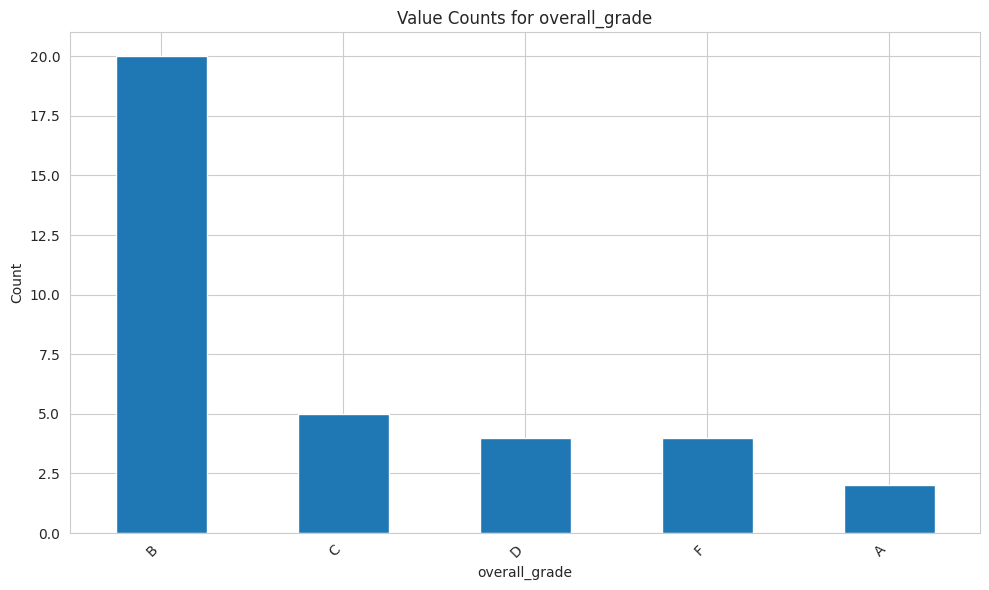

In [44]:
# 5. Run df['col'].value_counts() on at least 1 categorical column
# First, let's identify potential categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    # Choose the first categorical column for demonstration, or pick a relevant one
    selected_cat_col = categorical_cols[5]
    print(f"Value counts for categorical column: '{selected_cat_col}'")
    print(df[selected_cat_col].value_counts())

    # Plotting for better visualization
    plt.figure(figsize=(10, 6))
    df[selected_cat_col].value_counts().plot(kind='bar')
    plt.title(f'Value Counts for {selected_cat_col}')
    plt.xlabel(selected_cat_col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'value_counts_{selected_cat_col}.png') # Save the plot
    plt.show()
else:
    print("No categorical columns found in the dataset.")

## Data Visualization: Histograms

Generating histograms for numeric columns...


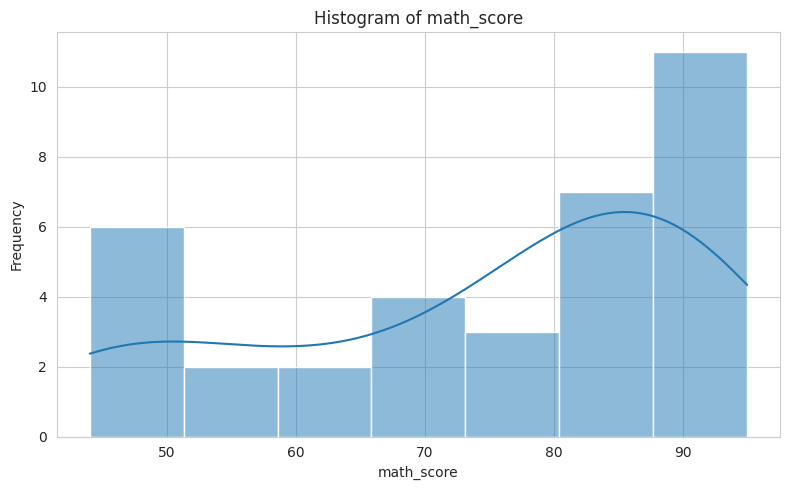

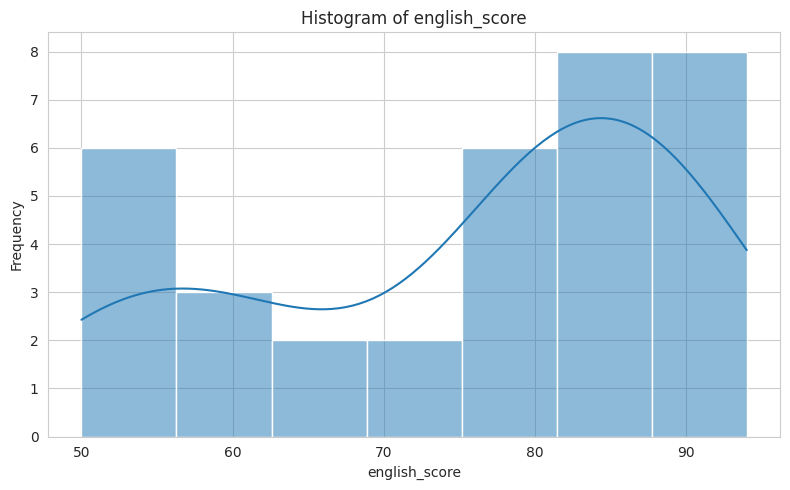

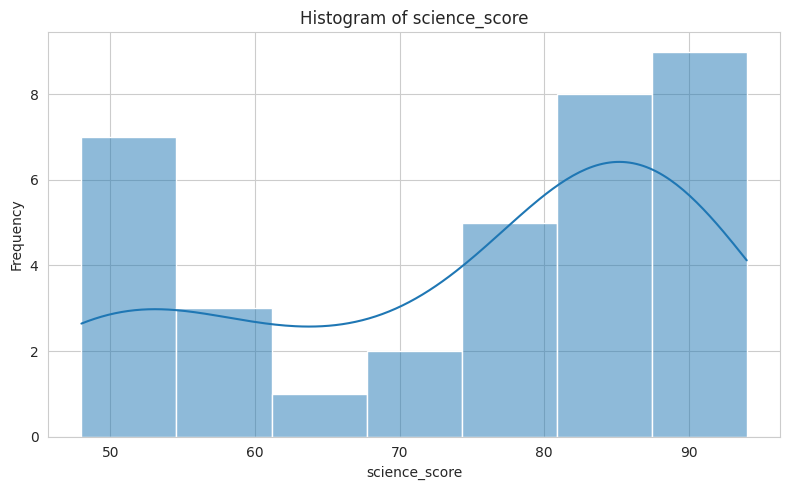

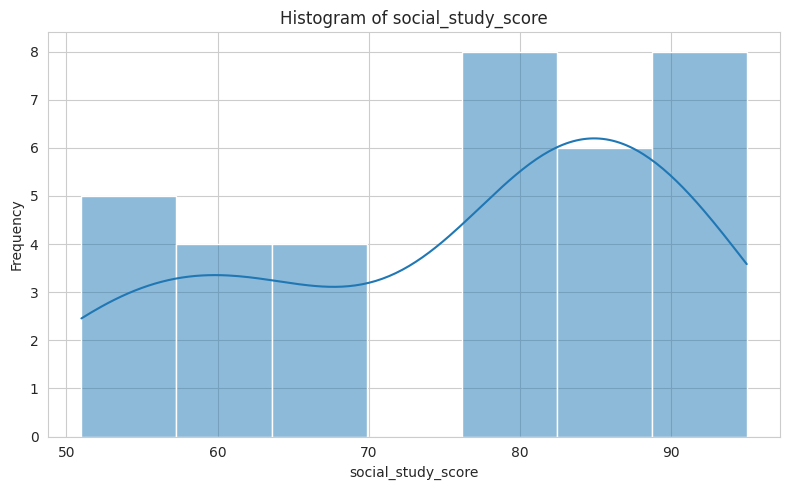

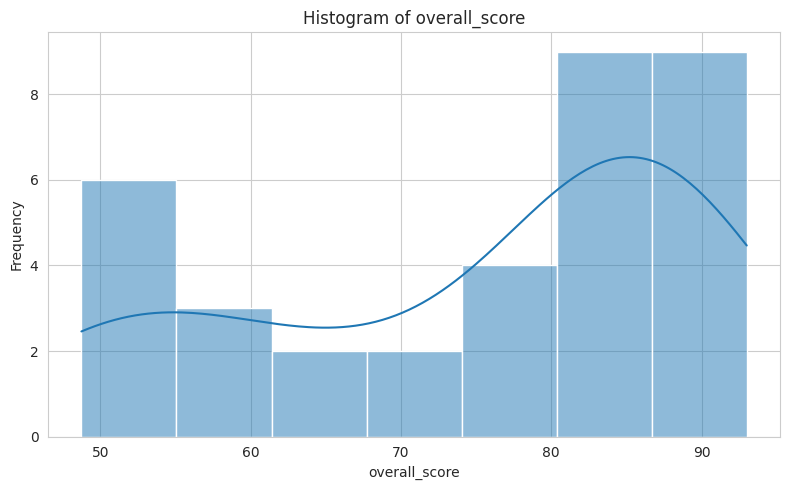

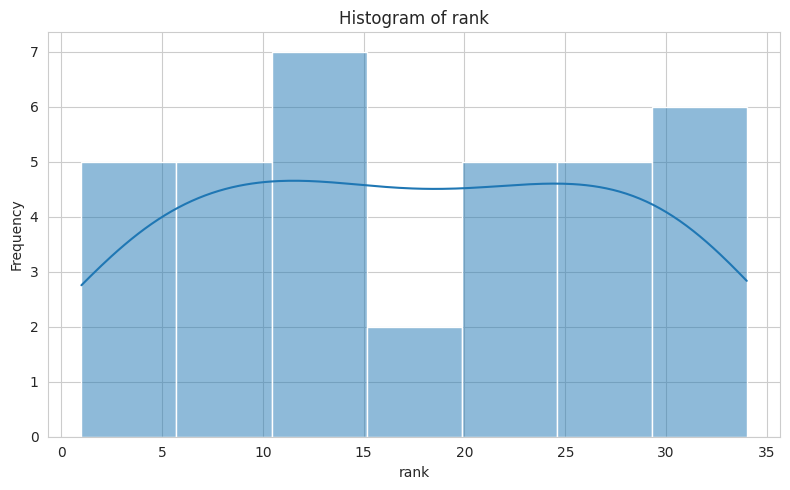

In [45]:
# 6. Plot a histogram for every numeric column
numeric_cols = df.select_dtypes(include=np.number).columns

if len(numeric_cols) > 0:
    print("Generating histograms for numeric columns...")
    for col in numeric_cols:
        plt.figure(figsize=(8, 5))
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.savefig(f'histogram_{col}.png') # Save the plot
        plt.show()
        # Document whether it looks normal or skewed
        # (e.g., Histogram of 'column_A' appears normally distributed.)
        # (e.g., Histogram of 'column_B' is right-skewed, with a long tail to the right.)
else:
    print("No numeric columns found for histograms.")

## Data Visualization: Box Plots

Generating a single combined plot for 6 numeric columns...


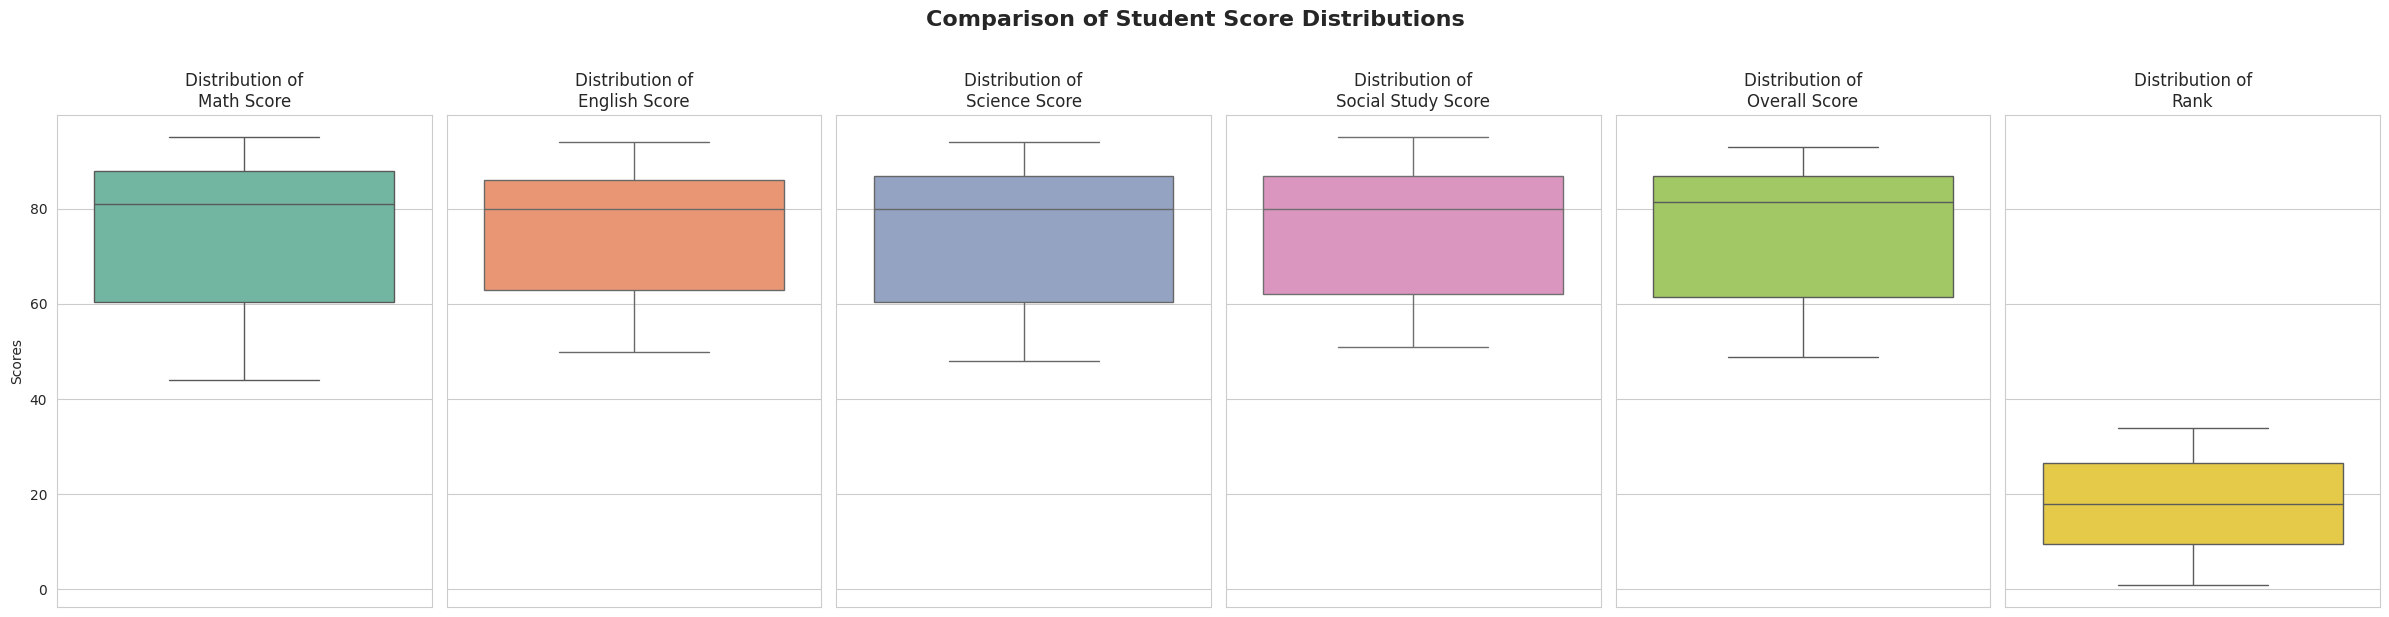


--- Outlier & Distribution Summary ---
* Box plot of 'math_score' appears to have no significant outliers.
* Box plot of 'english_score' appears to have no significant outliers.
* Box plot of 'science_score' appears to have no significant outliers.
* Box plot of 'social_study_score' appears to have no significant outliers.
* Box plot of 'overall_score' appears to have no significant outliers.
* Box plot of 'rank' appears to have no significant outliers.


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming numeric_cols = ['math_score', 'english_score', 'science_score', 'social_study_score']
# or dynamically generated from your dataframe:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

if len(numeric_cols) > 0:
    print(
        f"Generating a single combined plot for {len(numeric_cols)} numeric columns..."
    )

    # Set up the matplotlib figure grid dynamically based on the number of columns
    num_plots = len(numeric_cols)

    # We will arrange them in a single row if 4 or fewer, or wrap them if there are more
    fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 6), sharey=True)

    # If there's only 1 numeric column, 'axes' isn't returned as an array, so we wrap it
    if num_plots == 1:
        axes = [axes]

    # Plot each column on its respective subplot axis
    for i, col in enumerate(numeric_cols):
        # Using x=col instead of y=col gives you a neat vertical comparison if sharey=True
        sns.boxplot(data=df, y=col, ax=axes[i], color=sns.color_palette("Set2")[i % 8])
        axes[i].set_title(f"Distribution of\n{col.replace('_', ' ').title()}")
        axes[i].set_ylabel("Scores" if i == 0 else "")  # Only label the leftmost Y-axis
        axes[i].set_xlabel("")

    plt.suptitle("Comparison of Student Score Distributions", fontsize=16, weight="bold", y=1.02)
    plt.tight_layout()

    # Save the single, combined plot
    plt.savefig("combined_scores_boxplot.png", bbox_inches="tight", dpi=300)
    plt.show()

    # Documenting patterns & outliers dynamically
    print("\n--- Outlier & Distribution Summary ---")
    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        if not outliers.empty:
            print(
                f"* Box plot of '{col}' shows {len(outliers)} outlier(s) outside the whiskers."
            )
        else:
            print(f"* Box plot of '{col}' appears to have no significant outliers.")

else:
    print("No numeric columns found to generate plots.")

## Bonus: Pair Plot

Generating pair plot for all numeric columns... This may take a while for large datasets.


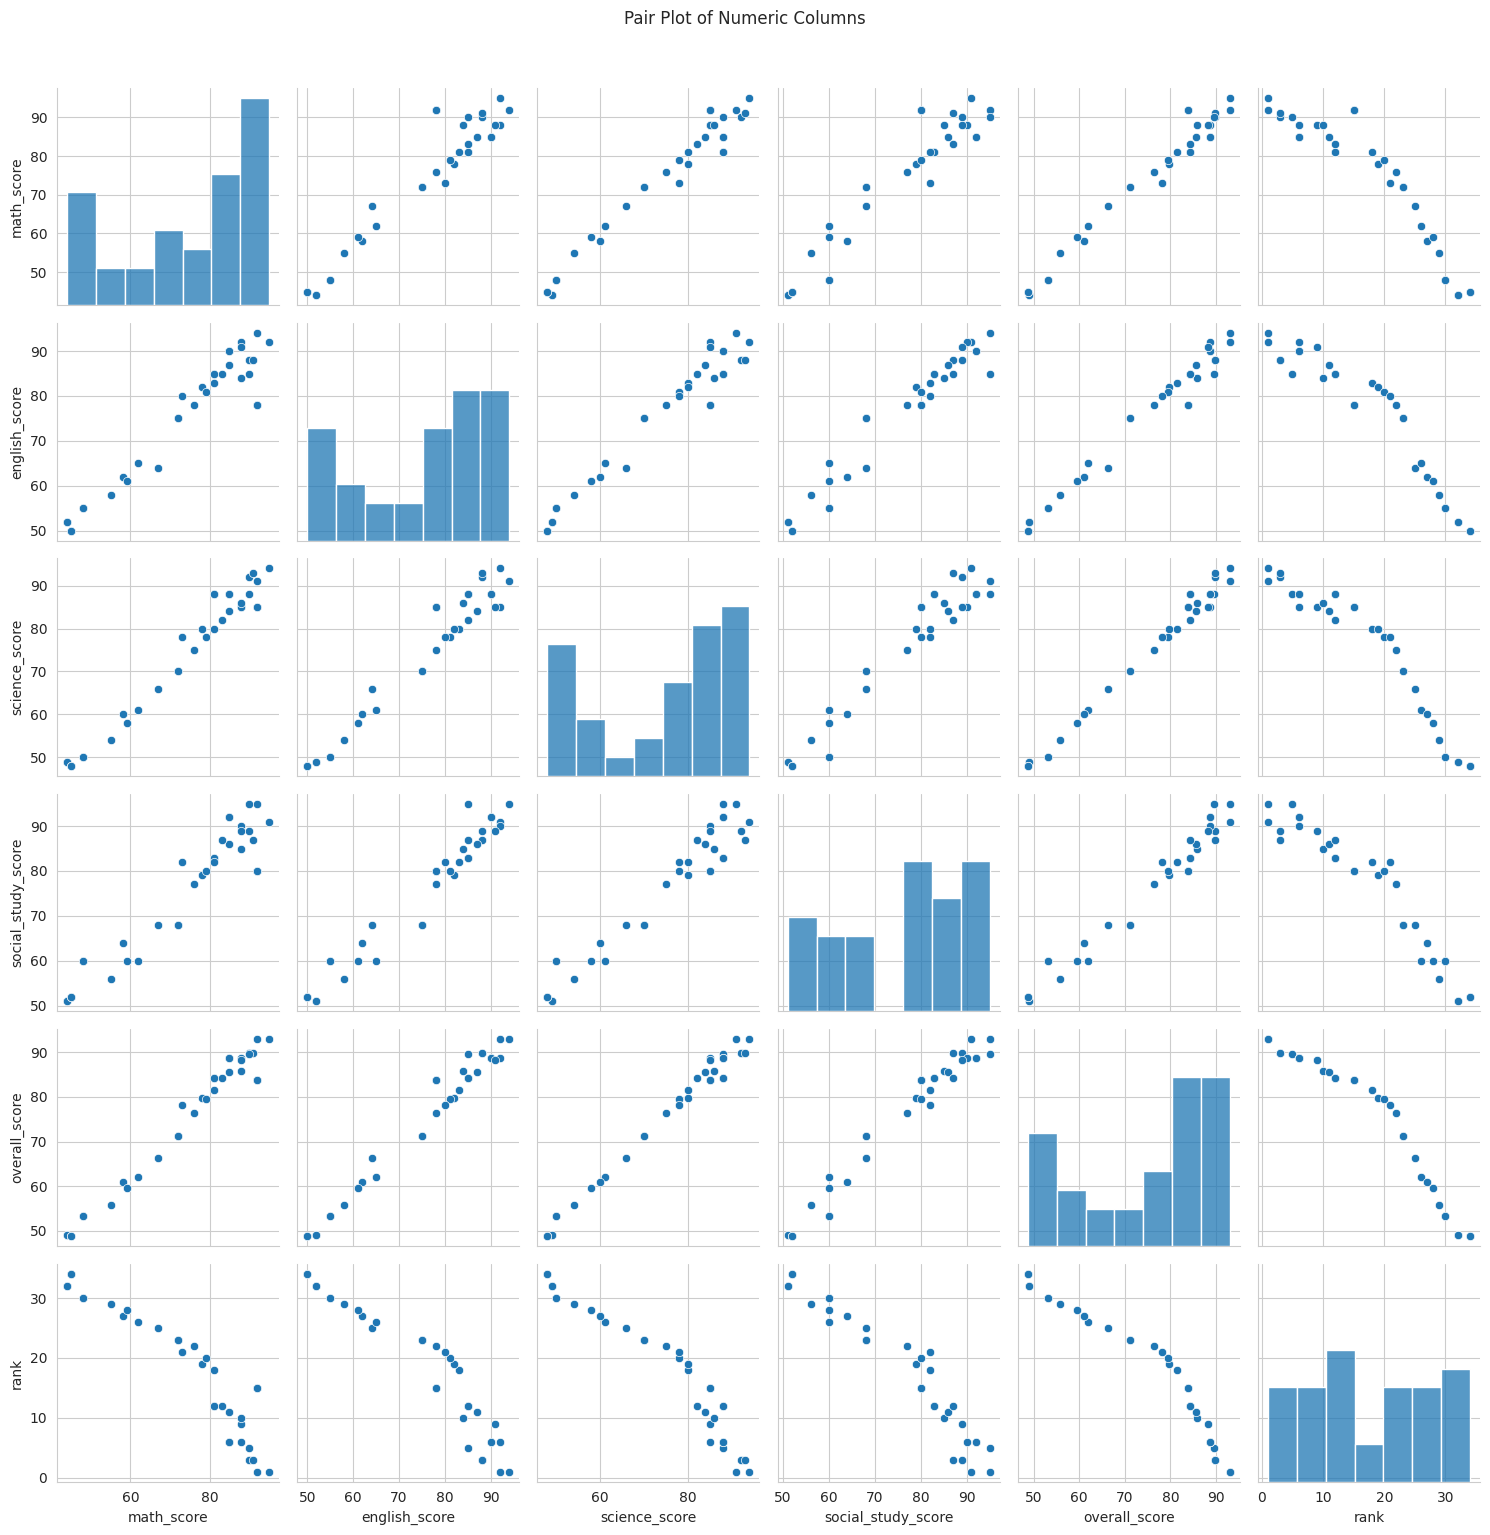

In [47]:
# Bonus: Use sns.pairplot() on all numeric columns
if len(numeric_cols) > 1:
    print("Generating pair plot for all numeric columns... This may take a while for large datasets.")
    # For very large datasets, consider sampling or selecting a subset of numeric columns
    pair_plot = sns.pairplot(df[numeric_cols].dropna())
    pair_plot.fig.suptitle('Pair Plot of Numeric Columns', y=1.02) # Adjust title position
    plt.tight_layout()
    plt.savefig('pairplot_numeric_columns.png') # Save the plot
    plt.show()
    # Describe what you see
    # (e.g., The scatter plots reveal a positive linear relationship between 'column_A' and 'column_B'.)
    # (e.g., 'column_C' appears to have a non-linear relationship with 'column_D'.)
    # (e.g., Histograms on the diagonal show the distribution of each variable individually, similar to previous histograms.)
else:
    print("Not enough numeric columns (at least two) to generate a pair plot.")

## Summary of Findings

<!-- 8. Write a 5-line comment block at the top summarising what you found -->

*   **Data Overview**: (e.g., The dataset contains X entries and Y features, primarily numerical and text-based categories.)
*   **Missing Data**: (e.g., Several columns, such as 'Z', have significant missing values (e.g., 25%), which will require imputation or removal.)
*   **Key Statistics**: (e.g., Descriptive statistics reveal that 'Feature A' is right-skewed, with its mean being higher than its median. 'Feature B' shows a suspicious minimum value.)
*   **Categorical Insights**: (e.g., The 'Category C' column is dominated by one or two unique values, suggesting potential imbalance if used in modeling.)
*   **Visual Patterns**: (e.g., Histograms indicate most numeric features are not normally distributed, often showing skewness. Box plots highlight the presence of outliers in 'Feature D' and 'Feature E', which might need further investigation or handling.)